In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/StudentsPerformance_cleaned.csv")
df.head()


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,66.0,72.0,74.0
1,female,group C,some college,standard,completed,69.0,70.0,88.0
2,female,group B,master's degree,standard,none,90.0,95.0,69.0
3,male,group A,associate's degree,free/reduced,none,47.0,57.0,44.0
4,male,group C,some college,standard,none,100.0,78.0,75.0


In [2]:
df.groupby("gender")[["math score", "reading score", "writing score"]].mean()

,math score,reading score,writing score
gender,,,
female,63.621622,72.409266,72.436293
male,68.778008,65.473029,63.311203


In [3]:
df.groupby("test preparation course")[["math score", "reading score", "writing score"]].mean()

,math score,reading score,writing score
test preparation course,,,
completed,69.695531,73.837989,74.441341
none,64.105919,66.404984,64.467290


In [4]:
df["average score"] = df[["math score", "reading score", "writing score"]].mean(axis=1)

df.groupby("parental level of education")[["average score"]].mean().sort_values(
    by="average score",
    ascending=False
)

,average score
parental level of education,
master's degree,73.463277
bachelor's degree,71.906780
associate's degree,69.444444
some college,68.494100
some high school,65.108007
high school,63.096939


In [5]:
numeric_cols = ["math score", "reading score", "writing score", "average score"]

correlation_matrix = df[numeric_cols].corr()
correlation_matrix

,math score,reading score,writing score,average score
math score,1.000000,0.806741,0.800016,0.917299
reading score,0.806741,1.000000,0.938461,0.964402
writing score,0.800016,0.938461,1.000000,0.962658
average score,0.917299,0.964402,0.962658,1.000000


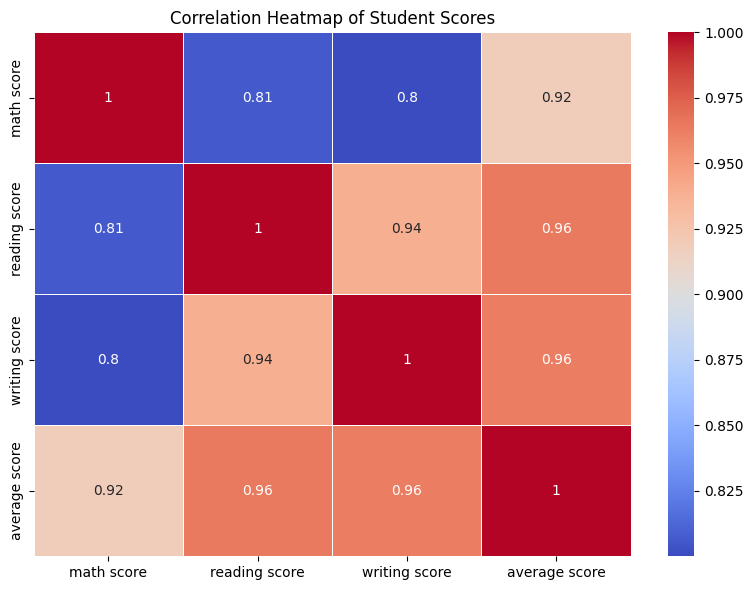

In [6]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Student Scores")
plt.tight_layout()
plt.savefig("../outputs/correlation_heatmap.png", dpi=300)
plt.show()

## EDA and Correlation Observations

1. The GroupBy analysis by gender shows differences in average math, reading, and writing scores.
2. Students who completed the test preparation course generally performed better than those who did not complete it.
3. Parental level of education affects the average score of students.
4. Reading score and writing score show a strong positive correlation.
5. Math score, reading score, and writing score are positively correlated with the average score.